In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import random
from wordcloud import WordCloud, STOPWORDS

In [3]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
train.head(5)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (2000, 8)
Test: (500, 7)


In [5]:
print(f"Missing values in train:\n{train.isnull().sum()}\n")

print(f"Missing values in test:\n{test.isnull().sum()}")

Missing values in train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in test:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [6]:
percentage = train['answer'].value_counts(normalize = True, ascending = False)*100

print(f"Distribution of correct answers:\n{percentage}")

Distribution of correct answers:
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64


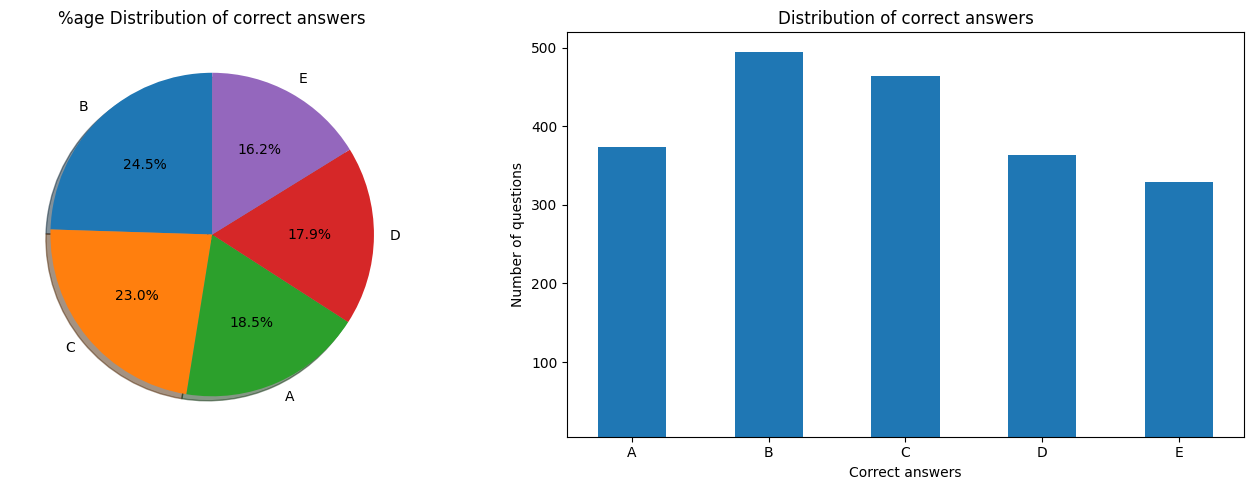

In [7]:
fig ,axes = plt.subplots(1,2 ,figsize = (14,5))

axes[0].pie(percentage, labels = percentage.index, autopct = '%1.1f%%' , shadow = True, startangle = 90)
axes[0].set_title('%age Distribution of correct answers')

#df used for bar chart
value = train['answer'].value_counts().sort_index()

axes[1].bar(value.index, value,width= 0.5, bottom = 5)
axes[1].set_title('Distribution of correct answers')
axes[1].set_xlabel('Correct answers')
axes[1].set_ylabel('Number of questions')

plt.tight_layout()
plt.show()

In [8]:
train['prompt_len'] = train['prompt'].str.len()

prompt_len_dis = train['prompt_len'].describe()
print(f"Prompt length distribution:\n{prompt_len_dis}")

Prompt length distribution:
count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64


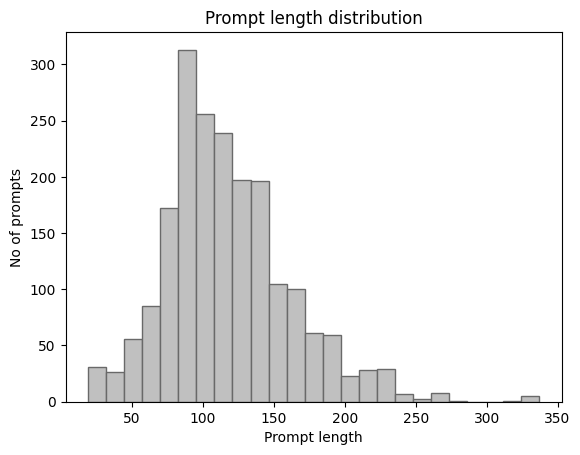

In [9]:
plt.hist(train['prompt_len'], bins = 25, edgecolor = 'dimgrey', color = 'silver',)
plt.title('Prompt length distribution')
plt.xlabel('Prompt length')
plt.ylabel('No of prompts')
plt.show()

In [10]:
value = train.groupby('answer')['prompt_len'].mean()

print(f"Avg prompt length for each correct answer:\n{value}")

Avg prompt length for each correct answer:
answer
A    124.888889
B    124.212245
C    111.039216
D    118.033520
E    108.543210
Name: prompt_len, dtype: float64


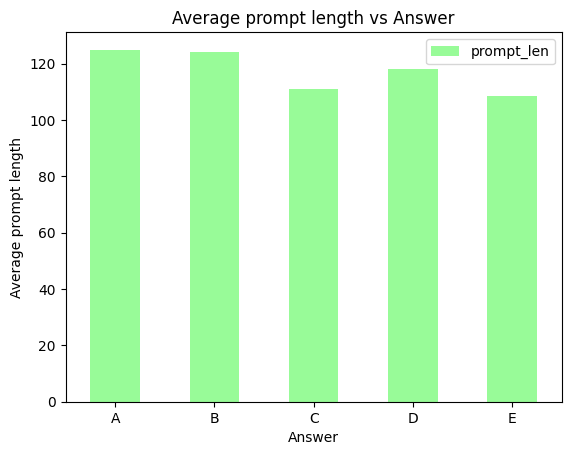

In [11]:
value.plot(kind = 'bar' , color = 'palegreen')
plt.title('Average prompt length vs Answer')
plt.xlabel('Answer')
plt.ylabel('Average prompt length')
plt.xticks(rotation = 0)
plt.legend()
plt.show()

### Baseline MAP@3 calculation for train dataset

In [12]:
def map_at3(prediction,correct):  #function to calculate MAP@3 score
  score = 0
  for pred, x in zip(prediction, correct):
    if x in pred:
      k = pred.index(x) + 1
      score += 1/k
  return round(score/len(correct) ,4)

In [13]:
# for top 3 answers

top3_ans = train['answer'].value_counts().index[0:3].tolist()
print(f"Top 3 most frequent answers: {top3_ans}")

top3_pred = [top3_ans] * len(train)
print(len(top3_pred))

correct_ans = train['answer'].tolist()
print("Baseline MAP@3 for top 3 most frequent answers:",map_at3(top3_pred, correct_ans))

Top 3 most frequent answers: ['B', 'C', 'A']
2000
Baseline MAP@3 for top 3 most frequent answers: 0.4213


In [14]:
# for random 3 answers
random.seed(42)
options = ['A', 'B','C','D','E']

random_pred = [random.sample(options , 3) for i in range(len(train))]  #list with elements as list of 3 random elements

print("Baseline MAP@3 for top 3 random answers:",map_at3(random_pred, correct_ans))

Baseline MAP@3 for top 3 random answers: 0.3675


### Generating a wordclound for the prompt data to see the most frequent words in the prompts.

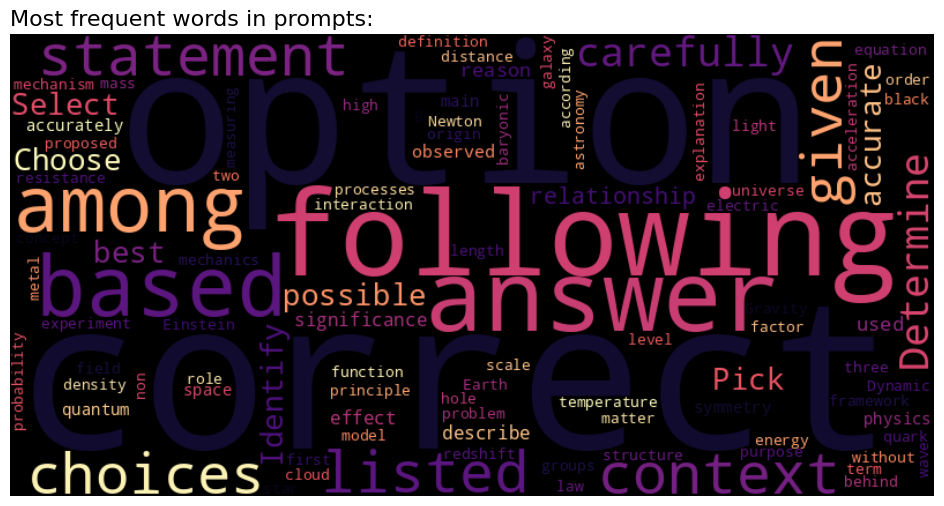

In [17]:
text = ' '.join(train['prompt'])

wordcloud = WordCloud(height = 400 ,
                      width = 800 ,
                      background_color = 'black' ,
                      max_words = 100,
                      colormap = 'magma' ,
                      stopwords = STOPWORDS,
                      collocations = False, 
                      random_state = 42).generate(text)

plt.figure(figsize = (12,6))
plt.imshow(wordcloud)
plt.title("Most frequent words in prompts:" , loc = 'left', fontsize = 16)
plt.axis('off')
plt.show()